<a href="https://colab.research.google.com/github/Fatimah-cloud/Depth-Anything/blob/main/Copy_of_lab10_visual_representations_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [ ]:
!pip install transformers datasets scikit-learn

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/378M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3680 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3669 [00:00<?, ? examples/s]

...

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

CLS token shape: (20, 384)
Predicted clusters:
[1 0 1 1 0 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1]

Ground Truth Labels:
[1 0 1 1 1 0 0 1 1 1 0 0 1 0 0 1 1 0 0 0]

Best Clustering Accuracy:
60.0 %

Confusion Matrix:
[[7 3]
 [5 5]]


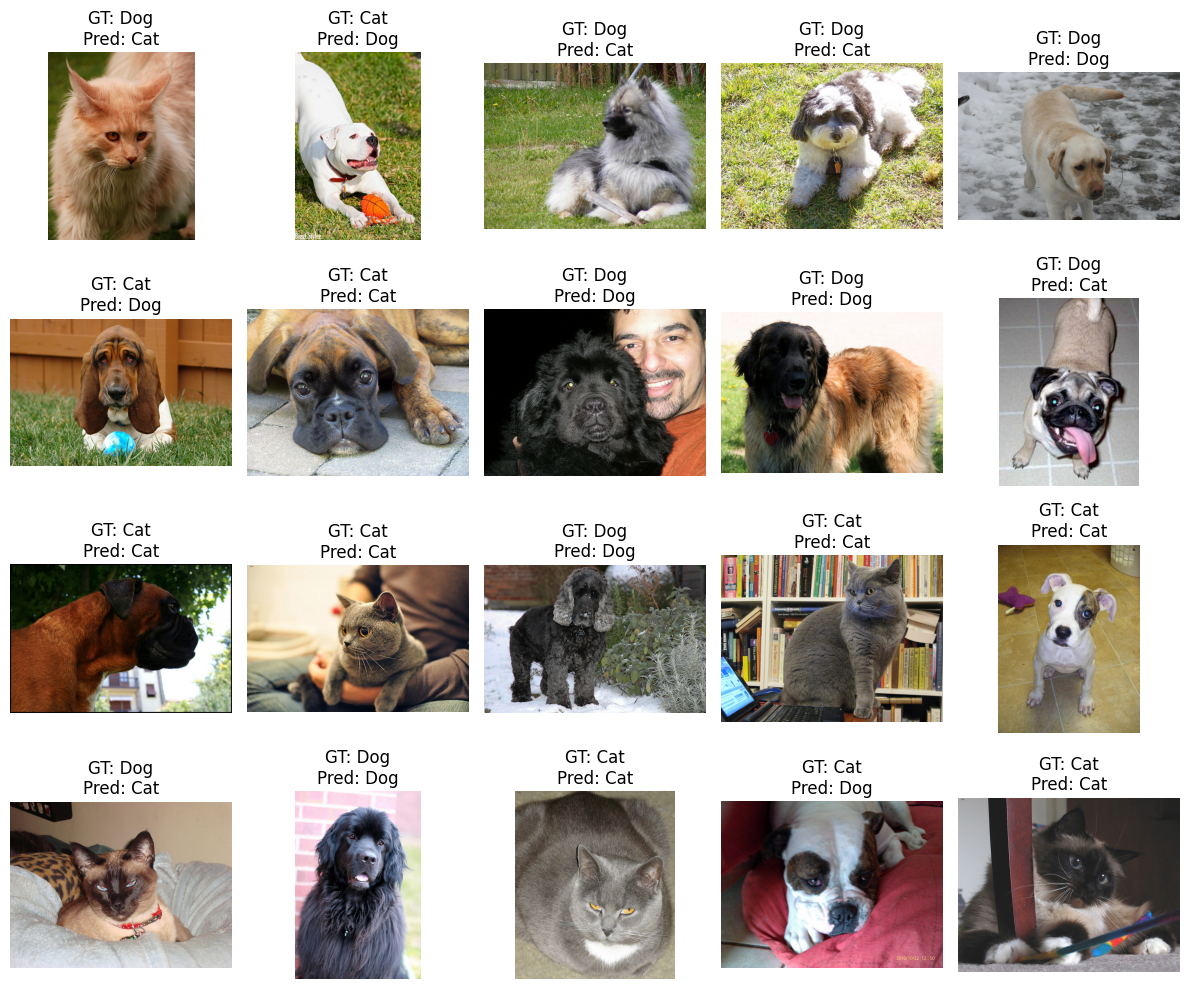

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from PIL import Image


dataset = load_dataset("timm/oxford-iiit-pet")

selected_images = []
selected_labels = []

cat_count = 0
dog_count = 0

for item in dataset["train"]:

    label = item["label"]



    if label <= 11 and cat_count < 10:
        selected_images.append(item["image"])
        selected_labels.append(0)
        cat_count += 1

    elif label > 11 and dog_count < 10:
        selected_images.append(item["image"])
        selected_labels.append(1)
        dog_count += 1

    if len(selected_images) == 20:
        break

print("Total selected images:", len(selected_images))



model_name = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.eval()



cls_tokens = []

with torch.no_grad():

    for image in selected_images:

        inputs = processor(images=image, return_tensors="pt")

        outputs = model(**inputs)


        cls_embedding = outputs.last_hidden_state[:, 0, :]

        cls_tokens.append(cls_embedding.squeeze().numpy())

cls_tokens = np.array(cls_tokens)

print("CLS token shape:", cls_tokens.shape)


kmeans = KMeans(n_clusters=2, random_state=42)

predicted_clusters = kmeans.fit_predict(cls_tokens)

print("Predicted clusters:")
print(predicted_clusters)


true_labels = np.array(selected_labels)



acc1 = accuracy_score(true_labels, predicted_clusters)
acc2 = accuracy_score(true_labels, 1 - predicted_clusters)

best_accuracy = max(acc1, acc2)

print("\nGround Truth Labels:")
print(true_labels)

print("\nBest Clustering Accuracy:")
print(best_accuracy * 100, "%")



if acc2 > acc1:
    predicted_clusters = 1 - predicted_clusters

cm = confusion_matrix(true_labels, predicted_clusters)

print("\nConfusion Matrix:")
print(cm)



fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for i, ax in enumerate(axes.flat):

    ax.imshow(selected_images[i])

    gt = "Cat" if true_labels[i] == 0 else "Dog"
    pred = "Cat" if predicted_clusters[i] == 0 else "Dog"

    ax.set_title(f"GT: {gt}\nPred: {pred}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [ ]:

import torch
import requests
from PIL import Image

from transformers import AutoImageProcessor
from transformers import AutoModelForImageClassification



model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)

model = AutoModelForImageClassification.from_pretrained(model_id)

model.eval()


url = "https://images.unsplash.com/photo-1552053831-71594a27632d"

image = Image.open(requests.get(url, stream=True).raw).convert("RGB")


image.show()


inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():

    outputs = model(**inputs)

logits = outputs.logits

predicted_class_idx = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_idx]

print("\nPredicted Class:")
print(predicted_label)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]


Predicted Class:
golden retriever
